<a href="https://colab.research.google.com/github/sevval-345/CNN/blob/main/U_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install torch torchvision --quiet

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


In [9]:
class UNet(nn.Module):
    """
    Basitleştirilmiş U-Net mimarisi.
    Giriş : (batch, in_ch, H, W)  -- örn. RGB görüntü (in_ch=3)
    Çıkış : (batch, num_classes, H, W) -- her piksel için sınıf skorları
    """
    def __init__(self, in_ch=3, num_classes=1, ozellikler=[64, 128, 256, 512]):
        super().__init__()

        self.encoder = nn.ModuleList()  # Daraltma yolundaki blokları tutacak liste
        self.decoder = nn.ModuleList()  # Genişletme yolundaki blokları tutacak liste
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Her encoder adımından sonra boyutu yarıya indirir

        # --- ENCODER (Daraltma Yolu) oluşturuluyor ---
        kanal = in_ch
        for f in ozellikler:
            self.encoder.append(ConvBlok(kanal, f))  # örn: 3->64, 64->128, 128->256, 256->512
            kanal = f

        # --- BOTTLENECK (En dar/derin katman, encoder ile decoder arasındaki köprü) ---
        self.bottleneck = ConvBlok(ozellikler[-1], ozellikler[-1] * 2)  # 512 -> 1024

        # --- DECODER (Genişletme Yolu) oluşturuluyor ---
        for f in reversed(ozellikler):
            # Transpoze konvolüsyon: özellik haritasının boyutunu 2 katına çıkarır (upsampling)
            self.decoder.append(
                nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2)
            )
            # Skip connection ile birleştirildikten sonra kanal sayısı 2 katına çıkar (f*2)
            self.decoder.append(ConvBlok(f * 2, f))

        # Son katman: kanal sayısını istenen sınıf sayısına indirir (1x1 konvolüsyon)
        self.son_katman = nn.Conv2d(ozellikler[0], num_classes, kernel_size=1)

    def forward(self, x):
        skip_baglantilari = []  # Her encoder seviyesinin çıktısını burada saklayacağız

        # --- Encoder'dan geçiş ---
        for enc_blok in self.encoder:
            x = enc_blok(x)                # Konvolüsyon bloğunu uygula
            skip_baglantilari.append(x)    # Havuzlamadan ÖNCEKİ hali sakla (decoder'a taşınacak)
            x = self.pool(x)               # Boyutu yarıya indir

        # --- Bottleneck ---
        x = self.bottleneck(x)  # En derin katman

        # Skip bağlantılarını decoder'da kullanmak için ters çeviriyoruz
        skip_baglantilari = skip_baglantilari[::-1]

        # --- Decoder'dan geçiş ---
        for i in range(0, len(self.decoder), 2):
            x = self.decoder[i](x)                    # Transpoze konvolüsyon ile boyutu büyüt
            skip = skip_baglantilari[i // 2]           # İlgili encoder seviyesinin sakladığı özellik haritası

            # Boyutlar (yuvarlama hatalarından dolayı) tam eşleşmeyebilir, gerekirse kırp
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])  # skip ile aynı H,W boyutuna getir

            x = torch.cat((skip, x), dim=1)           # KRİTİK ADIM: skip connection -> kanal boyutunda birleştir
            x = self.decoder[i + 1](x)                # ConvBlok ile işle

        return self.son_katman(x)  # Son 1x1 konvolüsyon ile sınıf haritasını üret

In [11]:
class ConvBlok(nn.Module):
    """
    U-Net'te tekrar tekrar kullanılan temel yapı taşı:
    (Konvolüsyon -> BatchNorm -> ReLU) x 2
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.blok = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.blok(x)

In [12]:
# U-Net modelini oluşturuyoruz: 3 kanallı (RGB) girdi, 1 sınıflı çıktı (örn. ikili segmentasyon: nesne/arkaplan)
model_unet = UNet(in_ch=3, num_classes=1).to(device)

# Sahte bir RGB görüntü batch'i: (batch=2, kanal=3, yükseklik=160, genişlik=160)
sahte_goruntu = torch.randn(2, 3, 160, 160).to(device)
maske_ciktisi = model_unet(sahte_goruntu)

print(f"Girdi boyutu : {sahte_goruntu.shape}")
print(f"Çıktı boyutu : {maske_ciktisi.shape}  # Girdiyle aynı H,W -> piksel bazlı segmentasyon haritası")

# Toplam öğrenilebilir parametre sayısı
toplam_param = sum(p.numel() for p in model_unet.parameters())
print(f"Toplam parametre sayısı: {toplam_param:,}")

Girdi boyutu : torch.Size([2, 3, 160, 160])
Çıktı boyutu : torch.Size([2, 1, 160, 160])  # Girdiyle aynı H,W -> piksel bazlı segmentasyon haritası
Toplam parametre sayısı: 31,043,521


In [13]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np

# Görüntü ve maske için ayrı dönüşümler tanımlıyoruz
goruntu_donusum = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def maske_donusum(maske):
    # Maskeyi 160x160'a getir (nearest: piksel değerlerini bozmadan, kesin sınıf etiketi olarak kalsın)
    maske = maske.resize((160, 160), Image.NEAREST)
    maske = np.array(maske, dtype=np.int64)
    # Oxford-IIIT Pet maskeleri: 1=nesne(hayvan), 2=arkaplan, 3=sınır çizgisi
    # Biz basitleştirip ikili hale getiriyoruz: hayvan=1, geri kalan=0
    maske = np.where(maske == 1, 1, 0).astype(np.float32)
    return torch.from_numpy(maske).unsqueeze(0)  # (1, 160, 160) -> kanal boyutu ekle

egitim_veri = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=goruntu_donusum,
    target_transform=maske_donusum,
)

test_veri = datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="segmentation",
    download=True,
    transform=goruntu_donusum,
    target_transform=maske_donusum,
)

egitim_loader = DataLoader(egitim_veri, batch_size=8, shuffle=True)
test_loader = DataLoader(test_veri, batch_size=8, shuffle=False)

print(f"Eğitim örneği sayısı: {len(egitim_veri)}")
print(f"Test örneği sayısı  : {len(test_veri)}")

# Bir örnek batch kontrol edelim
g, m = next(iter(egitim_loader))
print(f"Görüntü batch boyutu: {g.shape}")  # (8, 3, 160, 160)
print(f"Maske batch boyutu  : {m.shape}")  # (8, 1, 160, 160)

100%|██████████| 792M/792M [00:35<00:00, 22.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.8MB/s]


Eğitim örneği sayısı: 3680
Test örneği sayısı  : 3669
Görüntü batch boyutu: torch.Size([8, 3, 160, 160])
Maske batch boyutu  : torch.Size([8, 1, 160, 160])


In [14]:
model_unet = UNet(in_ch=3, num_classes=1).to(device)

criterion = nn.BCEWithLogitsLoss()  # İkili segmentasyon: her piksel için "hayvan mı değil mi"
optimizer = torch.optim.Adam(model_unet.parameters(), lr=1e-4)

In [15]:
EPOCH_SAYISI = 5

for epoch in range(EPOCH_SAYISI):
    model_unet.train()
    toplam_loss = 0.0

    for goruntuler, maskeler in egitim_loader:
        goruntuler, maskeler = goruntuler.to(device), maskeler.to(device)

        optimizer.zero_grad()
        ciktilar = model_unet(goruntuler)      # (batch, 1, 160, 160) - ham logit'ler
        loss = criterion(ciktilar, maskeler)   # Her piksel için hata hesaplanıp ortalanıyor
        loss.backward()
        optimizer.step()

        toplam_loss += loss.item()

    ortalama_loss = toplam_loss / len(egitim_loader)
    print(f"Epoch {epoch+1}/{EPOCH_SAYISI} - Ortalama Loss: {ortalama_loss:.4f}")

Epoch 1/5 - Ortalama Loss: 0.3706
Epoch 2/5 - Ortalama Loss: 0.2696
Epoch 3/5 - Ortalama Loss: 0.2364
Epoch 4/5 - Ortalama Loss: 0.2170
Epoch 5/5 - Ortalama Loss: 0.1949


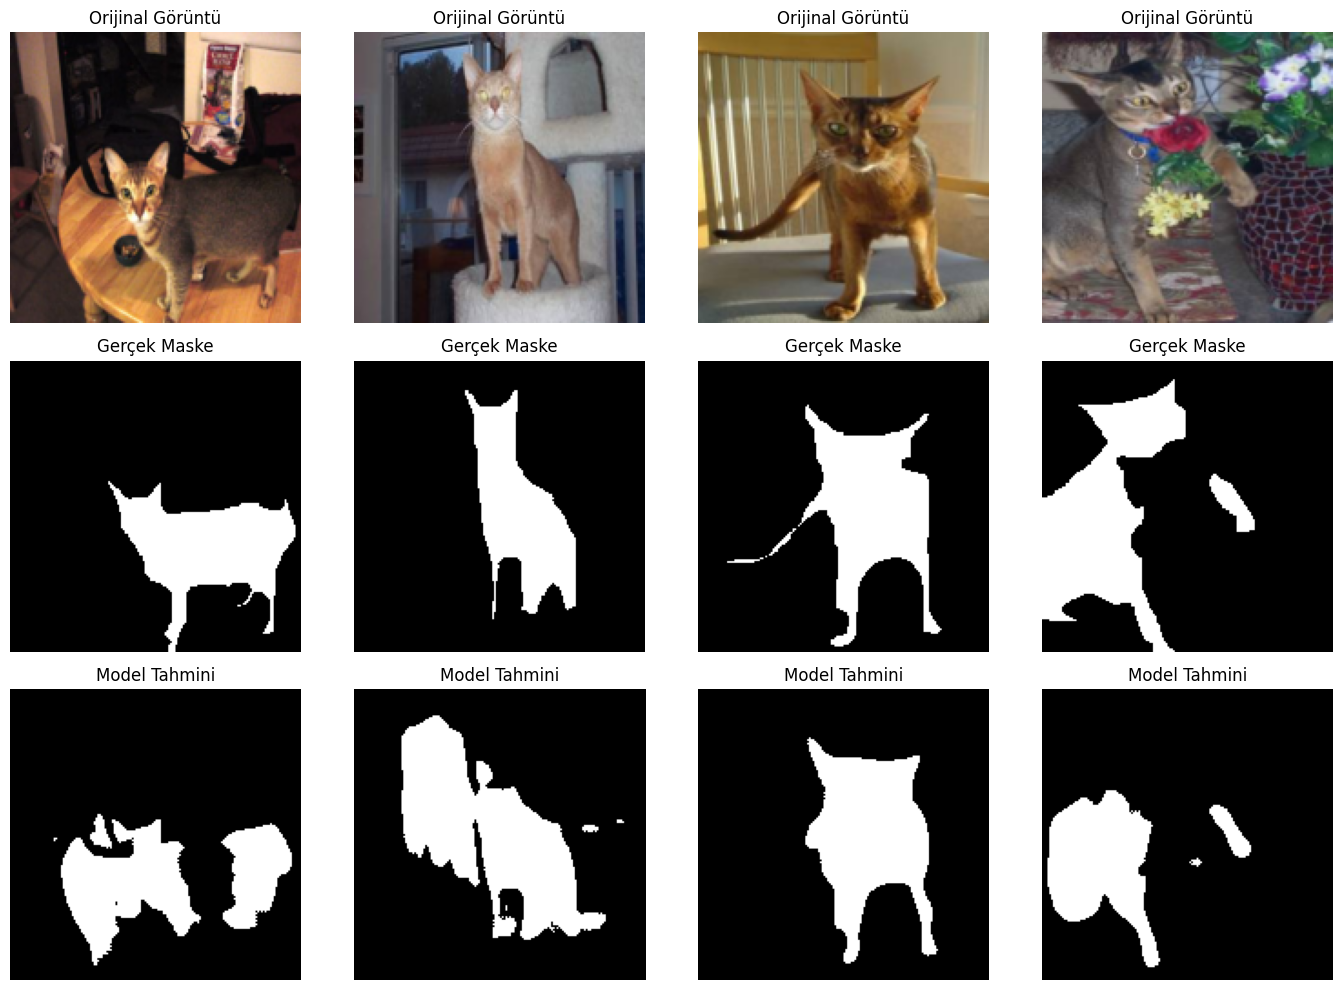

In [16]:
import matplotlib.pyplot as plt

model_unet.eval()

# Test setinden bir batch al
goruntuler, maskeler = next(iter(test_loader))
goruntuler, maskeler = goruntuler.to(device), maskeler.to(device)

with torch.no_grad():
    ciktilar = model_unet(goruntuler)
    tahmin_maskeler = (torch.sigmoid(ciktilar) > 0.5).float()  # Olasılığa çevirip eşikle

# Görselleştirme için normalize edilmiş görüntüyü geri çeviriyoruz (yaklaşık, sadece görsel amaçlı)
def goruntu_geri_cevir(tensor_img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    return img.permute(1, 2, 0).clamp(0, 1).numpy()

fig, eksenler = plt.subplots(3, 4, figsize=(14, 10))

for i in range(4):
    eksenler[0, i].imshow(goruntu_geri_cevir(goruntuler[i]))
    eksenler[0, i].set_title("Orijinal Görüntü")
    eksenler[0, i].axis("off")

    eksenler[1, i].imshow(maskeler[i, 0].cpu(), cmap="gray")
    eksenler[1, i].set_title("Gerçek Maske")
    eksenler[1, i].axis("off")

    eksenler[2, i].imshow(tahmin_maskeler[i, 0].cpu(), cmap="gray")
    eksenler[2, i].set_title("Model Tahmini")
    eksenler[2, i].axis("off")

plt.tight_layout()
plt.show()